# Multi Checkpoint Performance Analysis

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

METRIC_COLUMNS = ["collision", "offroad", "progress", "position_reached"]

In [8]:
def list_checkpoint_csvs(directory: Path) -> list[tuple[int, Path]]:
    """Return sorted checkpoint CSV files under one evaluation directory."""
    matches = []
    prefix = "eval-model_"
    for path in directory.glob(f"{prefix}*.csv"):
        if not path.stem.startswith(prefix):
            continue

        checkpoint_text = path.stem.removeprefix(prefix)
        if not checkpoint_text.isdigit():
            continue

        matches.append((int(checkpoint_text), path))
    return sorted(matches, key=lambda item: item[0])


def load_checkpoint_means(directory: Path) -> pd.DataFrame:
    """Load the final mean row from every checkpoint CSV."""
    rows = []
    for checkpoint_step, csv_path in list_checkpoint_csvs(directory):
        df = pd.read_csv(csv_path)
        if df.empty:
            continue

        mean_row = df.iloc[-1]
        if str(mean_row["number"]).strip() != "mean":
            continue

        rows.append(
            {
                "checkpoint": checkpoint_step,
                "collision": float(mean_row["collision"]),
                "offroad": float(mean_row["offroad"]),
                "progress": float(mean_row["progress"]),
                "position_reached": float(mean_row["position_reached"]),
                "total_episode_reward": float(mean_row["total_episode_reward"]),
            }
        )

    summary_df = pd.DataFrame(rows)
    if summary_df.empty:
        raise ValueError(f"No valid checkpoint CSV files found under {directory}")
    return summary_df.sort_values("checkpoint").reset_index(drop=True)


def plot_metric_curves(summary_df: pd.DataFrame, metric_columns: list[str]) -> None:
    """Plot multiple checkpoint metrics on one figure."""
    fig, ax = plt.subplots(figsize=(15, 5))
    for metric in metric_columns:
        ax.plot(
            summary_df["checkpoint"],
            summary_df[metric],
            marker="o",
            linewidth=1,
            label=metric,
        )

    ax.set_xlabel("Checkpoint Step")
    ax.set_ylabel("Mean Value")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

In [9]:
evaluation_dir = Path("/home/chen/thesis/Experiments/Baseline-10K-512steps/evaluation")
summary_df = load_checkpoint_means(evaluation_dir)
summary_df

,checkpoint,collision,offroad,progress,position_reached,total_episode_reward
0,1000,0.316,0.212,0.595614,0.197,125.381934
1,2000,0.433,0.572,0.538418,0.114,37.122559
2,3000,0.403,0.366,0.800333,0.446,78.749514
3,4000,0.415,0.344,0.811535,0.481,79.998887
4,5000,0.411,0.353,0.801733,0.448,77.721345
5,6000,0.391,0.319,0.804109,0.440,93.102635
6,7000,0.430,0.409,0.808976,0.463,78.581810


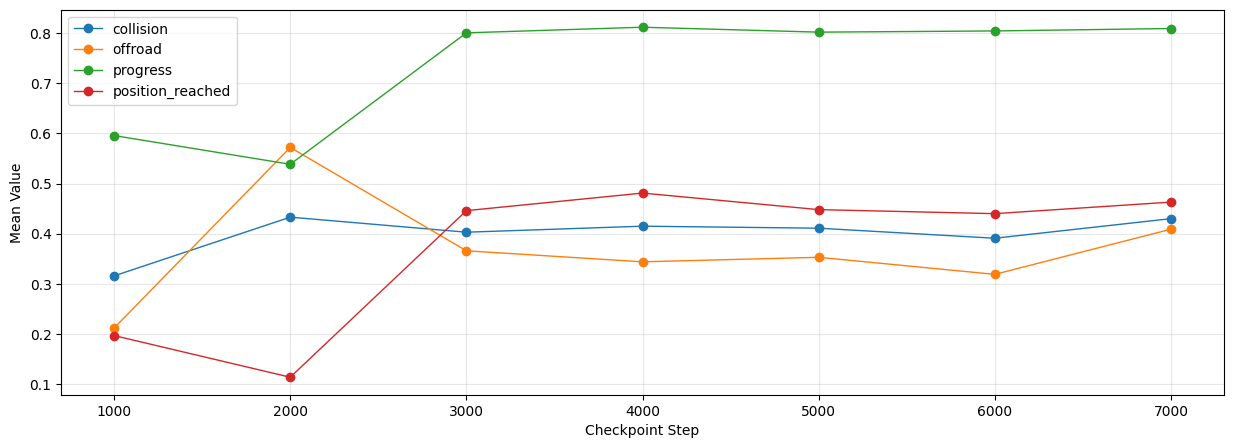

In [10]:
plot_metric_curves(summary_df, METRIC_COLUMNS)

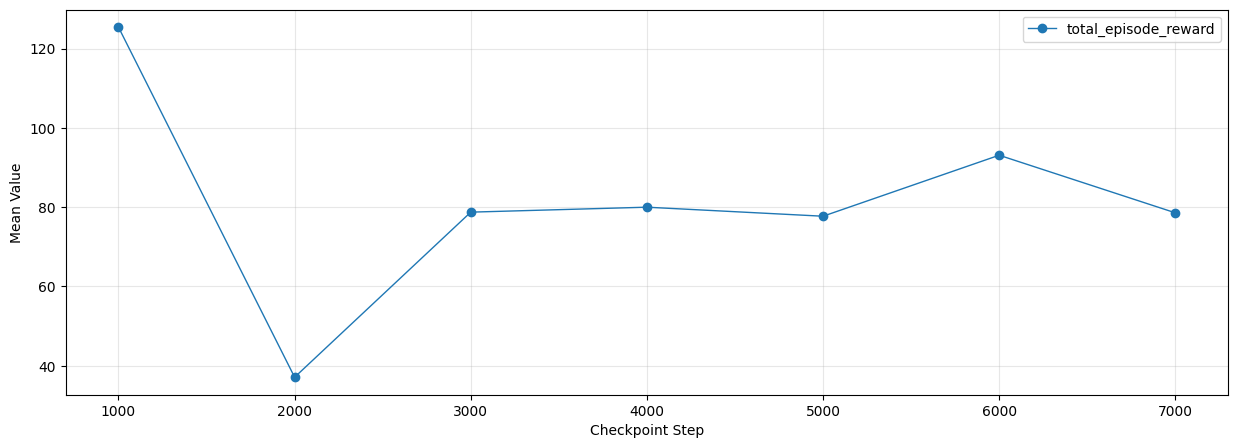

In [11]:
plot_metric_curves(summary_df, ["total_episode_reward"])